Load TSLA Data

In [7]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
from src import DataLoader, EDA, StationarityTester, RiskMetrics, ARIMAForecaster, LSTMForecaster
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
loader = DataLoader(["TSLA"], "2015-01-01", "2026-01-15")
loader.load_processed()
df = loader.data["TSLA"]
price = df['Close']
returns = price.pct_change().dropna()

 Train/Test Split

In [3]:
train_end = "2024-12-31"
train_ret = returns.loc[:train_end]
test_ret = returns.loc[train_end:].iloc[1:]
train_price = price.loc[:train_end]
test_price = price.loc[train_end:].iloc[1:]

Fit ARIMA

In [4]:
print("\n=== ARIMA(1,0,1) ===")
arima = ARIMAForecaster(train_ret, test_ret, order=(1,0,1))
arima.fit()
arima.forecast()
arima.convert_to_prices(train_price.iloc[-1])
arima_metrics = arima.evaluate(test_price)


=== ARIMA(1,0,1) ===
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3651
Model:                 ARIMA(1, 0, 1)   Log Likelihood                8079.047
Date:                Wed, 28 Jan 2026   AIC                         -16150.094
Time:                        15:18:14   BIC                         -16125.283
Sample:                    01-03-2015   HQIC                        -16141.258
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      2.386      0.017       0.000       0.002
ar.L1          0.5623      0.097      5.772      0.000       0.371       0.753
ma.L1         -0.4758      0.1

Plot

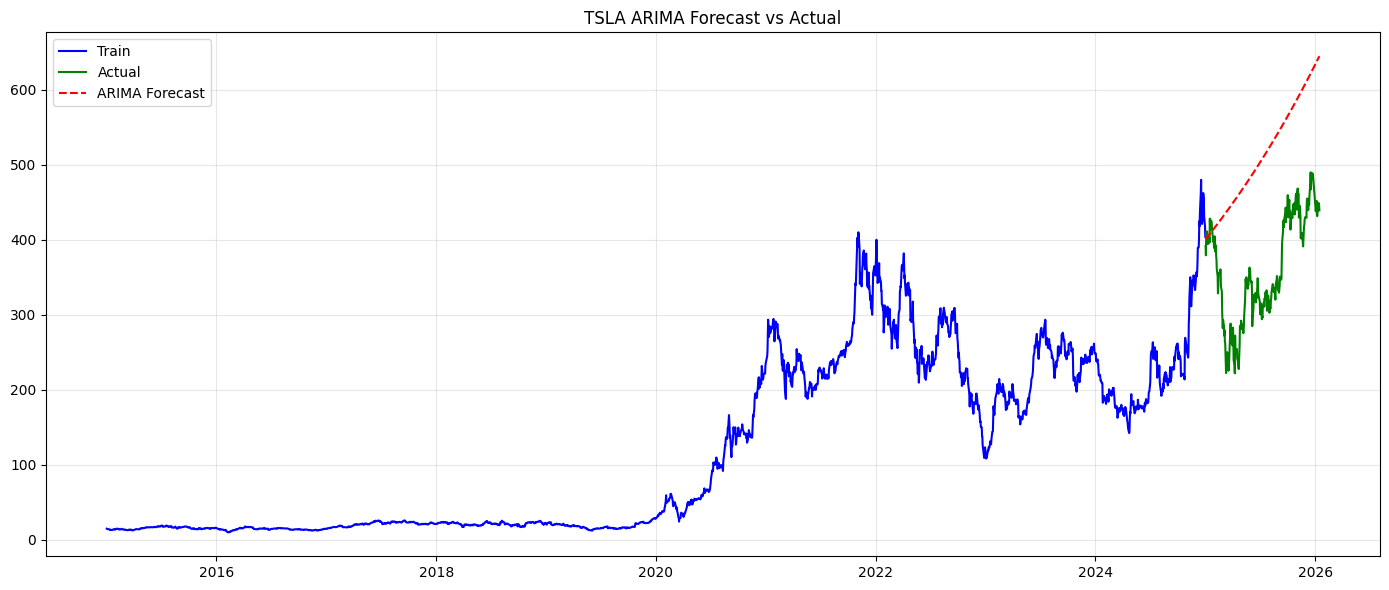

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(train_price.index, train_price.values, label="Train", color='blue')
plt.plot(test_price.index, test_price.values, label="Actual", color='green')
plt.plot(arima.forecast_prices.index, arima.forecast_prices.values, 
         label="ARIMA Forecast", color='red', linestyle='--')
plt.title("TSLA ARIMA Forecast vs Actual")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [8]:
 # Cell 5: LSTM Model
print("\n=== LSTM (60-day window) ===")
lstm = LSTMForecaster(train_ret, test_ret, window_size=60, epochs=20, batch_size=32)
lstm.fit()
lstm.forecast()
lstm.convert_to_prices(train_price.iloc[-1])
lstm_metrics = lstm.evaluate(test_price)


=== LSTM (60-day window) ===

LSTM Forecast Evaluation Metrics:
  MAE: $54.12
  RMSE: $65.67
  MAPE: 17.69%


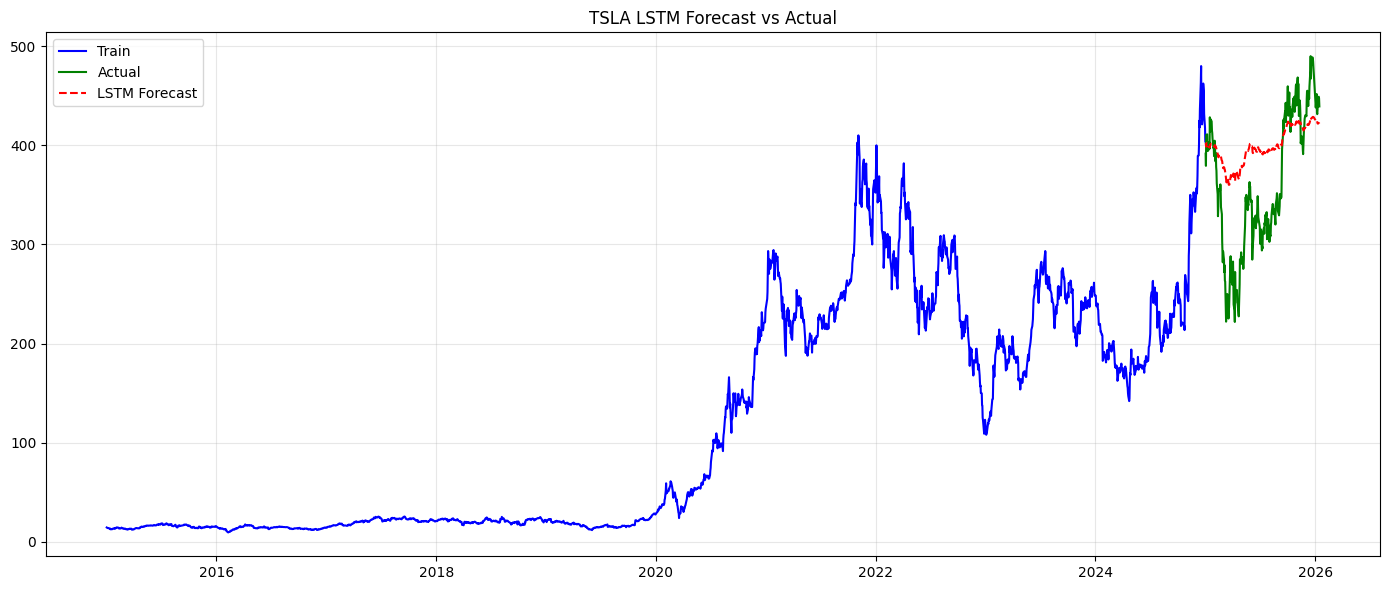

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(train_price.index, train_price.values, label="Train", color='blue')
plt.plot(test_price.index, test_price.values, label="Actual", color='green')
plt.plot(lstm.forecast_prices.index, lstm.forecast_prices.values, 
         label="LSTM Forecast", color='red', linestyle='--')
plt.title("TSLA LSTM Forecast vs Actual")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Model Comparison Table

In [10]:

import pandas as pd
comparison = pd.DataFrame({
    "ARIMA(1,0,1)": arima_metrics,
    "LSTM": lstm_metrics
}).T
print("\n=== Model Comparison ===")
print(comparison.round(2))



=== Model Comparison ===
                 MAE    RMSE   MAPE
ARIMA(1,0,1)  153.28  163.61  45.82
LSTM           54.12   65.67  17.69


Plot Both Forecasts

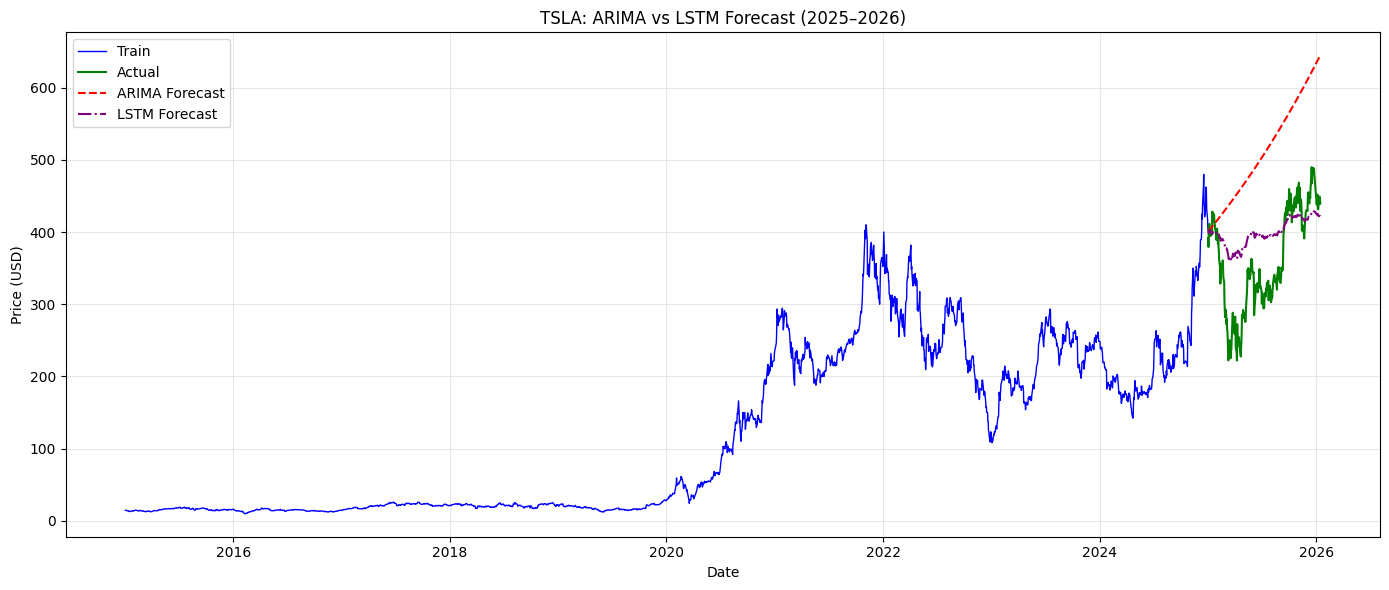

In [11]:

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
plt.plot(train_price.index, train_price.values, label="Train", color='blue', linewidth=1)
plt.plot(test_price.index, test_price.values, label="Actual", color='green', linewidth=1.5)
plt.plot(arima.forecast_prices.index, arima.forecast_prices.values, 
         label="ARIMA Forecast", color='red', linestyle='--')
plt.plot(lstm.forecast_prices.index, lstm.forecast_prices.values, 
         label="LSTM Forecast", color='purple', linestyle='-.')
plt.title("TSLA: ARIMA vs LSTM Forecast (2025–2026)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()